In [ ]:
# this project uses data collected about Hard Disks using S.M.A.R.T (Self-Monitoring, Analysis, and Reporting Technology) sensor logs. It is a very big set of data,
# it does sutisfy the orders for the project regarding the size of features and overall data and it even dramatically exceeds it, so we started by wrangling data:

In [ ]:
###########################################################################
# wrangling operation, by Bevnoty Mamdouh (Leader) ID: 2300536
###########################################################################

# first, we bring the libraries

import pandas as pd # for data manipulation
import glob # helps finding files with specific endings
import os # in case sm1 tries to run the code on a diffrent OS

# where to find the needed data to work on
folder_path = './data_Q4_2025/data_Q4_2025' # a text holding where the unzipped data is

# look for csv files inside it
all_files = glob.glob(os.path.join(folder_path, "*.csv")) # creates a list of all files inside of the 'folder_path' that ends in '.csv' aka excel files

# just in case, stop running if no files were found
if len(all_files) == 0: 
    raise FileNotFoundError("No CSV files found in: {folder_path}.") # helpful error message to edit the path and make sure everything is in its place bfr pandas start working on anything

print(f"Found {len(all_files)} files.processing... ") # a status update for calmness, reassuring me that the 92 files (one for each day of the last quarter of 2025) were found

sampled_chunks = [] # just a temporary holder of chunks of data that we will later on glue together

# 2. Loop through each daily file safely
for file in all_files: # start of the loop where the main action happens
    chunk_container = pd.read_csv(file, chunksize=50000) #this line is important cz it guards the device itself from crashing cz of lack of memory, by reading the data 50k rows a time then putting them in a holding place
    
    for chunk in chunk_container: 
        # loop through the 50k rows and Keep ALL rows where a drive actually failed cz it is more rare and valuable for the learning process
        failures = chunk[chunk['failure'] == 1] 
        
        # Keep only 0.5% of the healthy drives to safe guard the machine from class imbalance, the random state helps with the stability of the system, in case it was run again later, it should pick the exact same drives altho it is random
        healthy = chunk[chunk['failure'] == 0].sample(frac=0.005, random_state=42)
        
        # put results in its place
        sampled_chunks.append(failures)
        sampled_chunks.append(healthy)

# 3. Combine all the tiny chunks into one manageable DataFrame
final_df = pd.concat(sampled_chunks, ignore_index=True)

# 4. Save your new, optimized dataset!
final_df.to_csv('optimized_backblaze_data.csv', index=False) #basically glues everything together and make sure no index problem happens

print(f" new dataset has {final_df.shape[0]} rows and {final_df.shape[1]} features.")

# it took 2m 53s to run

Found 92 files.processing... 
 new dataset has 155655 rows and 197 features.


In [2]:
###########################################################################
# wrangling operation, by Bevnoty Mamdouh (Leader) ID: 2300536
###########################################################################

import pandas as pd # for data manipulation

# Load the optimised new file
df = pd.read_csv('optimized_backblaze_data.csv')

#  Drop text columns, because machine learning algorithms only understand numbers
metadata_cols = ['date', 'serial_number', 'model', 'capacity_bytes'] #this highlights the columns I want to delete
df = df.drop(columns=[col for col in metadata_cols if col in df.columns]) # this safely deletes the col, and I say safely cz in case the col isnt there it doesnt crash

#  Drop columns that are mostly empty
threshold = len(df) * 0.50 # let us look at half the features
df = df.dropna(thresh=threshold, axis=1) #now, if half of it is null, we just delete it cz it is of no use, if anything it will cause noise

# Fill any remaining blank spots with the median number, bcz the machine might crash when it sees even 1 null value
df = df.fillna(df.median(numeric_only=True)) 

#  Save the final file
df.to_csv('final_ML_ready_data.csv', index=False)

print(f"--- WRANGLING COMPLETE ---")
print(f"final dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

--- WRANGLING COMPLETE ---
final dataset has 155655 rows and 43 columns.


Loading the Wrangler's clean data...
Generating Correlation Heatmap...


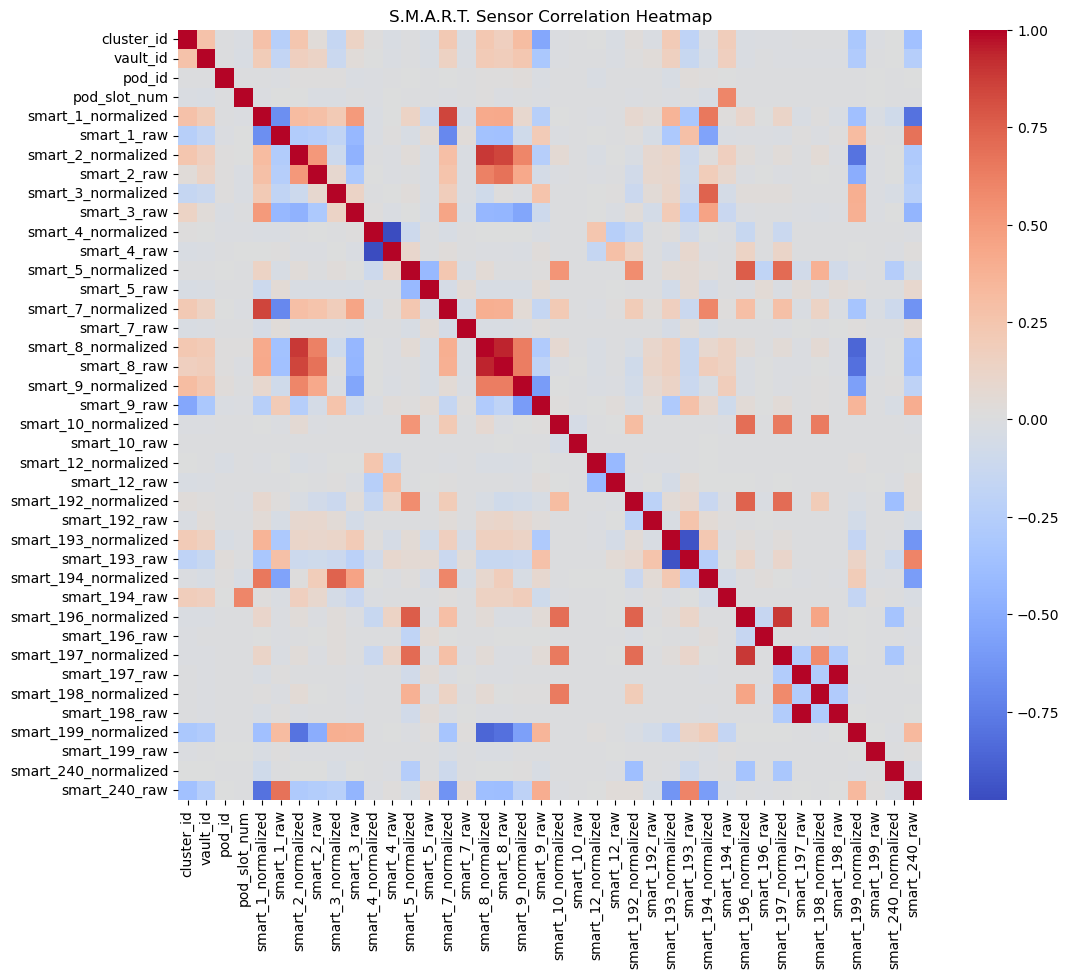


--- Running Feature Selection ---
Feature Selection kept the top 10 physical sensors:
 - smart_1_normalized
 - smart_3_normalized
 - smart_5_normalized
 - smart_5_raw
 - smart_7_raw
 - smart_196_raw
 - smart_197_normalized
 - smart_197_raw
 - smart_198_normalized
 - smart_198_raw


In [17]:
################################################################################################################################
# Dimensionality Expert, by Andrew Ashraf  ID : 2300540
################################################################################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# Load the final clean data
print("Loading the Wrangler's clean data...")
df = pd.read_csv('final_ML_ready_data.csv')

# Separate features x and target y
X = df.drop(columns=['failure'])
y = df['failure']

# remove any non-numeric columns
X = X.select_dtypes(include=[np.number])


# Visualaising the problem (Correlation)
print("Generating Correlation Heatmap...")
plt.figure(figsize=(12, 10))
# Calculate correlation matrix
corr_matrix = X.corr()
# draw the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("S.M.A.R.T. Sensor Correlation Heatmap")
plt.show()


# Split into training and testing sets
# make 20% of data for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# make all data on the same scale 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





#  Feature Selection (SelectKBest)
print("\n--- Running Feature Selection ---")
# keep only the 10 most significant sensors and rank them
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# print the names of the top 10 columns
winning_columns = X.columns[selector.get_support()]
print(f"Feature Selection kept the top 10 physical sensors:")
for col in winning_columns:
    print(f" - {col}")

Training Baseline Models...
Baseline Models Training Complete


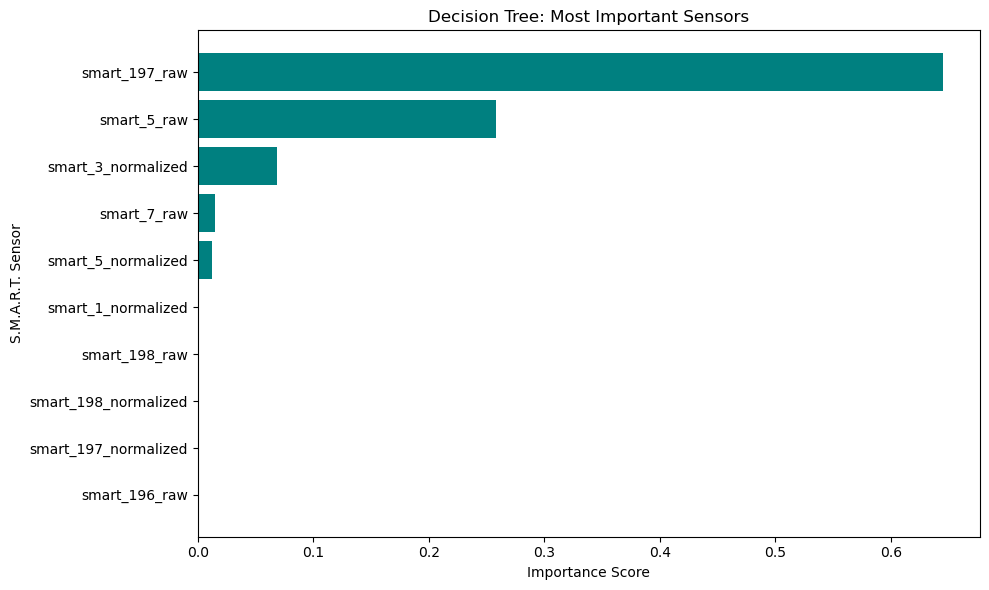

In [14]:
############################################################
# Baseline Modeler
############################################################

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("Training Baseline Models...")

# Logistic Regression Model
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_selected, y_train)

log_pred = log_model.predict(X_test_selected)


# Decision Tree Model
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    random_state=42
)
tree_model.fit(X_train_selected, y_train)

tree_pred = tree_model.predict(X_test_selected)

print("Baseline Models Training Complete")

#############################
tree_importances = tree_model.feature_importances_

tree_df = pd.DataFrame({
    'Sensor': winning_columns,
    'Importance Score': tree_importances
}).sort_values(by='Importance Score', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(tree_df['Sensor'], tree_df['Importance Score'], color='teal')
plt.xlabel("Importance Score")
plt.ylabel("S.M.A.R.T. Sensor")
plt.title("Decision Tree: Most Important Sensors")
plt.tight_layout()
plt.show()

Training Random Forest Model...
Random Forest Training Complete

Plotting Random Forest Feature Importance...


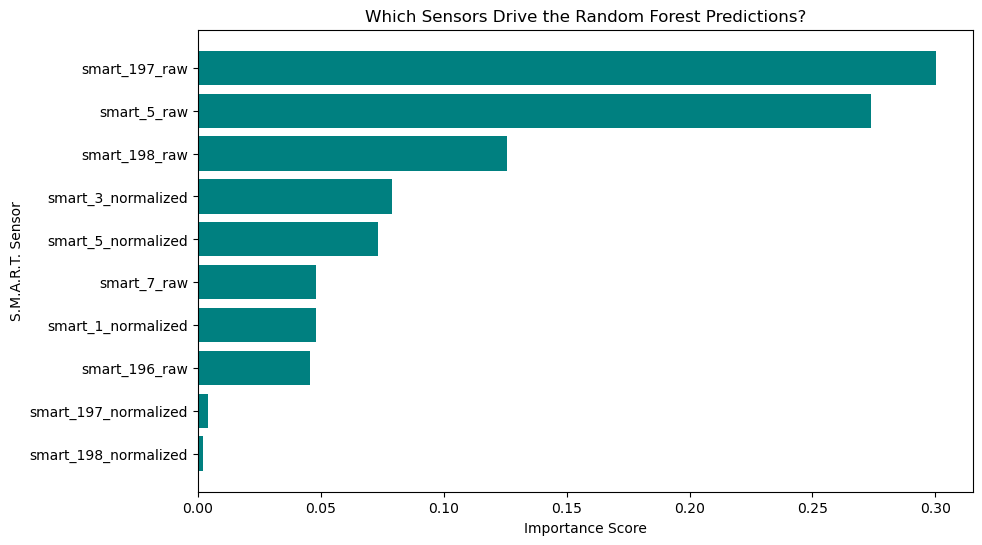

In [15]:
############################################################
# Advanced Modeler
############################################################

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Model...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_selected, y_train)

rf_pred = rf_model.predict(X_test_selected)

print("Random Forest Training Complete")

#######################################

print("\nPlotting Random Forest Feature Importance...")

# Extract the importance scores and match them to the sensor names
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Sensor': winning_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Draw the horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Sensor'], importance_df['Importance'], color='teal')
plt.xlabel("Importance Score")
plt.ylabel("S.M.A.R.T. Sensor")
plt.title("Which Sensors Drive the Random Forest Predictions?")
plt.show()


===== Logistic Regression Results =====


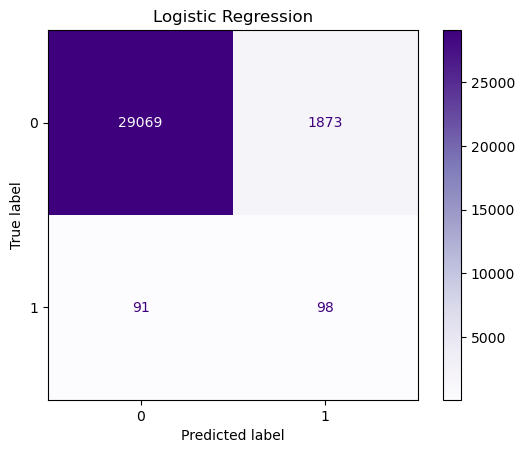

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30942
           1       0.05      0.52      0.09       189

    accuracy                           0.94     31131
   macro avg       0.52      0.73      0.53     31131
weighted avg       0.99      0.94      0.96     31131


===== Decision Tree Results =====


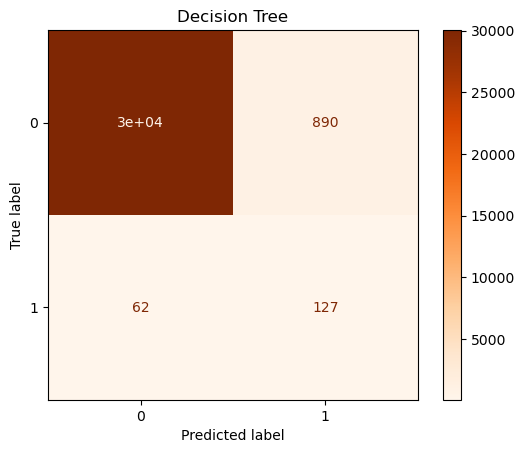

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     30942
           1       0.12      0.67      0.21       189

    accuracy                           0.97     31131
   macro avg       0.56      0.82      0.60     31131
weighted avg       0.99      0.97      0.98     31131


===== Random Forest Results =====


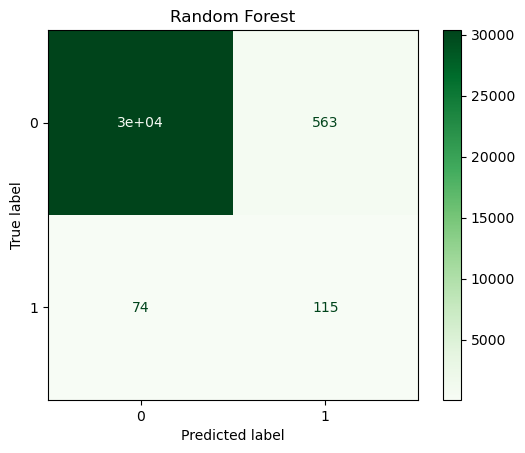

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     30942
           1       0.17      0.61      0.27       189

    accuracy                           0.98     31131
   macro avg       0.58      0.80      0.63     31131
weighted avg       0.99      0.98      0.99     31131



In [19]:
############################################################
# Model Evaluation
############################################################
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt 
print("\n===== Logistic Regression Results =====")

ConfusionMatrixDisplay.from_predictions(y_test, log_pred, cmap='Purples')
plt.title("Logistic Regression")
plt.show()
print(classification_report(y_test, log_pred))


print("\n===== Decision Tree Results =====")

ConfusionMatrixDisplay.from_predictions(y_test, tree_pred, cmap='Oranges')
plt.title("Decision Tree")
plt.show()
print(classification_report(y_test, tree_pred))


print("\n===== Random Forest Results =====")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap='Greens')
plt.title("Random Forest")
plt.show()
print(classification_report(y_test, rf_pred))


In [ ]:
# If Backblaze wants maximum data safety and doesn't mind paying engineers to check a lot of false alarms, The Decision Tree model is the best because it catches 67% of all crashes.
# If Backblaze wants the most balanced system that catches 61% of crashes but saves money by minimizing false alarms, The Random Forest model is our top recommendation.